# One image, three ways into a language model

Use a small pretrained **DeiT-Tiny vision encoder** and **DistilGPT2 language model**. Each connection takes **8–10 lines** after shared setup. We will see the actual image features, token IDs, tensor dimensions, vocabulary scores and generated text.

**These are working connections, not trained VLMs.** The vision encoder and language backbone are pretrained separately. Our projector, extra cross-attention layers and query resampler start with random weights. Output may be nonsense or ignore the image. The goal is to understand where the vectors go.

Run all cells in order in Colab (CPU is sufficient; a GPU is optional). The first run downloads public model weights, roughly 380 MB total, and one course image. No API key, training dataset or paid service is needed. Saved outputs come from an actual CPU run; other devices may give slightly different logits.

[Lecture](https://nipunbatra.github.io/attention/from-clip-to-vlm/?present#visual-states) · [DeiT-Tiny model](https://huggingface.co/facebook/deit-tiny-patch16-224) · [DistilGPT2 model](https://huggingface.co/distilbert/distilgpt2) · [Image credits](https://nipunbatra.github.io/attention/from-clip-to-vlm/SOURCES.md)

In [1]:
# Colab supplies torch, Pillow and matplotlib. Pin the model API used below.
import sys, subprocess
if "google.colab" in sys.modules:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers==4.57.6"])
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## Shared setup: load the two backbones once

DeiT-Tiny is a ViT trained on ImageNet. It uses a **224 × 224** input and **16 × 16** patches: **14 × 14 = 196 patch tokens**, plus one CLS token. Each encoder row has **192 features**.

DistilGPT2 uses **768 features per token** and a vocabulary of **50,257 token IDs**. It is a text-completion model, not an instruction-tuned assistant. `Question:` and `Answer:` below are ordinary tokenized text.

`add_cross_attention=True` adds a cross-attention sublayer inside each GPT-2 block, between causal self-attention and its MLP. Those extra weights are **new and untrained**; the checkpoint did not contain them. They are used only when we pass `encoder_hidden_states`. Ideas 1 and 3 skip them. This is the lecture's generic separate-memory connection, not an implementation of Flamingo.

In [2]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found.*")
import torch
from torch import nn
from transformers import AutoImageProcessor, AutoModel, AutoTokenizer, GPT2LMHeadModel
from transformers.utils import logging
from PIL import Image
from pathlib import Path
from urllib.request import urlopen
from IPython.display import display, Markdown
import matplotlib.pyplot as plt

torch.manual_seed(7)
torch.set_num_threads(4)
torch.set_grad_enabled(False)  # inference only in this notebook
device = "cuda" if torch.cuda.is_available() else "cpu"
VISION, VR = "facebook/deit-tiny-patch16-224", "b3428f18dcc7b543470d07f14b4a4157815d1880"
LANGUAGE, LR = "distilbert/distilgpt2", "2290a62682d06624634c1f46a6ad5be0f47f38aa"
logging.set_verbosity_error()  # report the expected new cross-attention weights explicitly below
processor = AutoImageProcessor.from_pretrained(VISION, revision=VR, use_fast=False)
vision = AutoModel.from_pretrained(VISION, revision=VR, add_pooling_layer=False).to(device).eval()
tokenizer = AutoTokenizer.from_pretrained(LANGUAGE, revision=LR)
lm, loading = GPT2LMHeadModel.from_pretrained(LANGUAGE, revision=LR,
    add_cross_attention=True, attn_implementation="eager", output_loading_info=True)
lm = lm.to(device).eval()
print("Device:", device, "| pretrained ViT width:", vision.config.hidden_size)
print("LM width:", lm.config.n_embd, "| vocabulary:", lm.config.vocab_size)
print("New untrained cross-attention parameter tensors:", len(loading["missing_keys"]))
assert loading["missing_keys"] and all("crossattention" in k or "ln_cross_attn" in k for k in loading["missing_keys"])

Device: cpu | pretrained ViT width: 192
LM width: 768 | vocabulary: 50257
New untrained cross-attention parameter tensors: 48


## Look at the actual image and text inputs

Left: the course photograph. Right: the **processed image actually given to the encoder**, with the 14 × 14 patch grid. Resizing/cropping and normalization belong to the image processor.

The answer-so-far is already supplied: **“It is a”**. The final supplied token will predict the next one. GPT-2 tokenization is displayed below; words and tokens are not assumed to be the same thing.

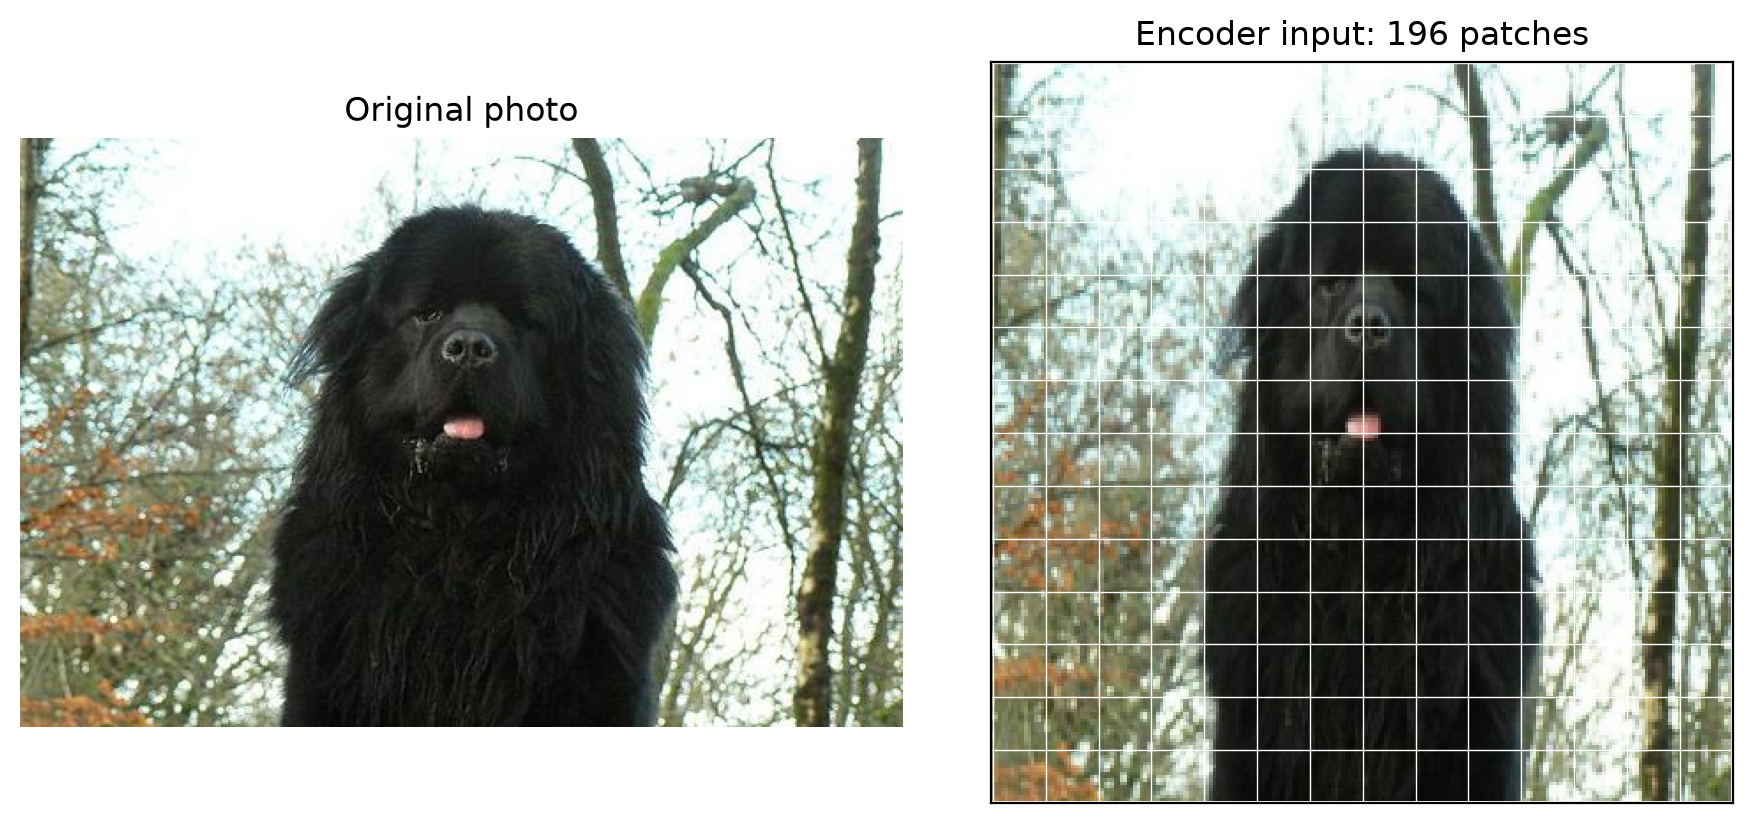

Question: What animal is shown?
Answer: It is a
Pixels: (1, 3, 224, 224) | text IDs: (1, 13)


| Position | Token ID | Decoded piece |
|---|---|---|
| 0 | 24361 | `'Question'` |
| 1 | 25 | `':'` |
| 2 | 1867 | `' What'` |
| 3 | 5044 | `' animal'` |
| 4 | 318 | `' is'` |
| 5 | 3402 | `' shown'` |
| 6 | 30 | `'?'` |
| 7 | 198 | `'\n'` |
| 8 | 33706 | `'Answer'` |
| 9 | 25 | `':'` |
| 10 | 632 | `' It'` |
| 11 | 318 | `' is'` |
| 12 | 257 | `' a'` |

In [3]:
local_image = Path("../figures/dog.jpg")
image = Image.open(local_image if local_image.exists() else urlopen(
    "https://nipunbatra.github.io/attention/from-clip-to-vlm/figures/dog.jpg")).convert("RGB")
question, answer_so_far = "What animal is shown?", "It is a"
prompt = f"Question: {question}\nAnswer: {answer_so_far}"
pixels = processor(images=image, return_tensors="pt")["pixel_values"].to(device)
ids = tokenizer(prompt, return_tensors="pt")["input_ids"].to(device)
visible_pixels = pixels[0].cpu().permute(1, 2, 0) * torch.tensor(processor.image_std) + torch.tensor(processor.image_mean)
fig, axes = plt.subplots(1, 2, figsize=(9, 4), layout="constrained")
axes[0].imshow(image); axes[0].set_title("Original photo"); axes[0].axis("off")
axes[1].imshow(visible_pixels.clamp(0, 1)); axes[1].set_title("Encoder input: 196 patches")
axes[1].set_xticks(range(0, 225, 16)); axes[1].set_yticks(range(0, 225, 16))
axes[1].grid(color="white", linewidth=.5); axes[1].tick_params(labelbottom=False, labelleft=False, length=0)
plt.show()
print(prompt)
print("Pixels:", tuple(pixels.shape), "| text IDs:", tuple(ids.shape))
display(Markdown("| Position | Token ID | Decoded piece |\n|---|---|---|\n" + "\n".join(
    f"| {i} | {t} | `{tokenizer.decode([t])!r}` |" for i,t in enumerate(ids[0].tolist()))))

## Encode the image; inspect the two widths

The encoder returns **197 rows**. Drop only the global CLS row, keeping **all 196 contextual patch rows**. Their 192 coordinates are actual pretrained features, not named semantic attributes. We show the first few coordinates of one row for readability; the complete tensor remains in the computation.

The language embedding lookup maps each token ID into a **768-coordinate row**. It has one vocabulary row per token ID. GPT-2 adds learned position embeddings inside its transformer. In the prefix examples, text positions come after the image-derived positions.

In [4]:
encoded = vision(pixel_values=pixels).last_hidden_state
H_v = encoded[:, 1:, :]  # remove CLS; retain all 196 patch rows
text_embeddings = lm.get_input_embeddings()(ids)
print("ViT output:", tuple(encoded.shape), "→ patch features:", tuple(H_v.shape))
print("Text embeddings:", tuple(text_embeddings.shape), "| vocabulary table:", tuple(lm.get_input_embeddings().weight.shape))
print("Patch 0, first 6 features:", H_v[0, 0, :6].cpu().tolist())
print("Last text token:", repr(tokenizer.decode(ids[0, -1:])), "| first 6 embedding features:", text_embeddings[0, -1, :6].cpu().tolist())

ViT output: (1, 197, 192) → patch features: (1, 196, 192)
Text embeddings: (1, 13, 768) | vocabulary table: (50257, 768)
Patch 0, first 6 features: [-0.7764105200767517, 0.5498924851417542, -1.069884181022644, -1.041081428527832, -3.0064857006073, -1.498595118522644]
Last text token: ' a' | first 6 embedding features: [-0.08173293620347977, 0.015382898040115833, 0.026177553460001945, -0.09752106666564941, -0.08089748024940491, -0.053862135857343674]


## Prepare the three small, untrained pieces

- **Projector:** 192 → 768 features per row. The number of rows stays the same.
- **Eight query slots:** parameters that a trained summarizer would learn; here they are random initial values.
- **Attention reader:** eight queries read all 196 visual rows, producing eight new mixtures. It does not choose a subset of eight patches.

We reuse one projector and one language backbone for all three methods. No weights are updated. The setup and display helper below are shared; the actual connections are visible in the short cells that follow.

In [5]:
projector = nn.Linear(vision.config.hidden_size, lm.config.n_embd).to(device).eval()
slots = nn.Parameter(torch.randn(1, 8, vision.config.hidden_size, device=device) * 0.02)
reader = nn.MultiheadAttention(vision.config.hidden_size, num_heads=3, batch_first=True).to(device).eval()
print("Projector weight:", tuple(projector.weight.shape), "(PyTorch stores output × input)")
print("Query slots:", tuple(slots.shape), "| reader heads:", reader.num_heads)

Projector weight: (768, 192) (PyTorch stores output × input)
Query slots: (1, 8, 192) | reader heads: 3


In [6]:
# Display only: all attention/concatenation/decoder calculations remain in the cells below.
def report(name, logits, states):
    display(Markdown(f"### {name}"))
    rows = [(key, tuple(value.shape)) for key,value in states.items()]
    rows += [("last text state", tuple(states["decoder states"][:, -1].shape)),
             ("vocabulary head weight", tuple(lm.lm_head.weight.shape)), ("next-token logits", tuple(logits.shape))]
    display(Markdown("| Tensor | Shape |\n|---|---|\n" + "\n".join(f"| {k} | {v} |" for k,v in rows)))
    scores, top = logits[0].softmax(-1).topk(5)
    display(Markdown("| Token ID | Decoded vocabulary piece | Probability |\n|---|---|---|\n" + "\n".join(
        f"| {i} | `{tokenizer.decode([i])!r}` | {p:.4f} |" for i,p in zip(top.tolist(), scores.tolist()))))
    print("Greedy next token:", repr(tokenizer.decode(logits.argmax(-1).tolist())))

## Idea 1: prepend all projected image rows

`image → ViT → 196 rows → projector → [196 visual rows | text rows] → causal decoder → vocabulary head`

Both modalities have width 768 before concatenation. The ordinary lower-triangular causal mask applies to the **whole combined sequence**, including its visual prefix; text can read all earlier image rows. The ViT has already used full image attention. `h[:, -1]` selects the last supplied text position, and `lm_head` maps its 768 numbers to 50,257 vocabulary logits. Argmax in the display helper picks an ID; the tokenizer decodes it.

In [7]:
def prefix(ids):
    visual = projector(H_v)
    text = lm.get_input_embeddings()(ids)
    x = torch.cat([visual, text], dim=1)
    h = lm.transformer(inputs_embeds=x).last_hidden_state
    return lm.lm_head(h[:, -1]), {"visual prefix": visual, "decoder input": x, "decoder states": h}
logits, states = prefix(ids)
report("All patch rows as a prefix", logits, states)

### All patch rows as a prefix

| Tensor | Shape |
|---|---|
| visual prefix | (1, 196, 768) |
| decoder input | (1, 209, 768) |
| decoder states | (1, 209, 768) |
| last text state | (1, 768) |
| vocabulary head weight | (50257, 768) |
| next-token logits | (1, 50257) |

| Token ID | Decoded vocabulary piece | Probability |
|---|---|---|
| 1664 | `' company'` | 0.0140 |
| 1178 | `' few'` | 0.0111 |
| 582 | `' man'` | 0.0098 |
| 4508 | `' brand'` | 0.0086 |
| 1263 | `' big'` | 0.0082 |

Greedy next token: ' company'


## Idea 2: keep the visual memory separate

`image → ViT → projector → separate memory → decoder cross-attention`

`text IDs → embeddings → causal self-attention → cross-attention → MLP → … → vocabulary head`

`encoder_hidden_states=memory` activates the extra cross-attention inside each GPT-2 block. Its **Q comes from the current text states; K and V come from the projected image memory**. Text self-attention is causal; the visual lookup can read all 196 memory rows. The decoder still has only T text positions, not 196 + T. Here the memory projector also matches GPT-2's required memory width of 768.

In [8]:
def separate_memory(ids):
    memory = projector(H_v)
    text = lm.get_input_embeddings()(ids)
    h = lm.transformer(inputs_embeds=text, encoder_hidden_states=memory).last_hidden_state
    return lm.lm_head(h[:, -1]), {"separate image memory": memory, "decoder input": text, "decoder states": h}
logits, states = separate_memory(ids)
report("Text reads separate image memory", logits, states)

### Text reads separate image memory

| Tensor | Shape |
|---|---|
| separate image memory | (1, 196, 768) |
| decoder input | (1, 13, 768) |
| decoder states | (1, 13, 768) |
| last text state | (1, 768) |
| vocabulary head weight | (50257, 768) |
| next-token logits | (1, 50257) |

| Token ID | Decoded vocabulary piece | Probability |
|---|---|---|
| 845 | `' very'` | 0.0257 |
| 3290 | `' dog'` | 0.0206 |
| 1692 | `' human'` | 0.0183 |
| 4257 | `' male'` | 0.0175 |
| 1402 | `' small'` | 0.0175 |

Greedy next token: ' very'


## Idea 3: summarize first, then prepend

`image → ViT → 196 rows → eight learned-query readers → 8 summaries → projector → [8 summaries | text] → causal decoder`

In `reader(q, H_v, H_v)`, the slots supply queries and the image rows supply keys and values. Every summary mixes information from all 196 rows. This is a minimal learned-query attention reader, not the full Q-Former or Perceiver Resampler. We choose the **prefix** route after compression here; a shorter memory could also feed Idea 2.

In [9]:
def compressed_prefix(ids):
    q = slots.expand(H_v.shape[0], -1, -1)
    summary, _ = reader(q, H_v, H_v)
    visual = projector(summary)
    text = lm.get_input_embeddings()(ids)
    x = torch.cat([visual, text], dim=1)
    h = lm.transformer(inputs_embeds=x).last_hidden_state
    return lm.lm_head(h[:, -1]), {"summary queries": q, "visual summaries": summary, "decoder input": x, "decoder states": h}
logits, states = compressed_prefix(ids)
report("Eight summary rows as a prefix", logits, states)

### Eight summary rows as a prefix

| Tensor | Shape |
|---|---|
| summary queries | (1, 8, 192) |
| visual summaries | (1, 8, 192) |
| decoder input | (1, 21, 768) |
| decoder states | (1, 21, 768) |
| last text state | (1, 768) |
| vocabulary head weight | (50257, 768) |
| next-token logits | (1, 50257) |

| Token ID | Decoded vocabulary piece | Probability |
|---|---|---|
| 4257 | `' male'` | 0.0394 |
| 1588 | `' large'` | 0.0326 |
| 1402 | `' small'` | 0.0280 |
| 2042 | `' black'` | 0.0191 |
| 845 | `' very'` | 0.0190 |

Greedy next token: ' male'


## Use the same next-token loop for all three

Append the predicted ID to the text and run again. Each new final text position has the earlier answer tokens available. The image encoding stays fixed. This short loop recomputes the full decoder prefix; it deliberately omits a KV cache to keep the mechanism visible. We cap it at eight new tokens rather than claiming the answer is complete.

**These are actual outputs of the untrained connections.** Fluent text does not mean that the answer is grounded in the image. Meaningful VLM behavior requires training the new connections (and, depending on the recipe, some backbone weights).

In [10]:
connections = {"1 · Full visual prefix": prefix, "2 · Separate memory": separate_memory, "3 · Short visual prefix": compressed_prefix}
for name, connect in connections.items():
    generated = ids.clone()
    for _ in range(8):
        next_logits, _ = connect(generated)
        generated = torch.cat([generated, next_logits.argmax(-1, keepdim=True)], dim=1)
    print(name, "→", repr(tokenizer.decode(generated[0, ids.shape[1]:], skip_special_tokens=False)))

1 · Full visual prefix → ' company.\n\n\n\n\n\n'


2 · Separate memory → ' very small animal, but it is very'
3 · Short visual prefix → ' male male male male male male male male'


## Check that the image path is connected

For each method, replace the encoded image features by zeros and compare the **next-token logits**. A nonzero difference shows that the numerical path is active; it does not show that the random connector understands images. The top token can remain unchanged even when logits move.

In [11]:
original_features = H_v
try:
    for name, connect in connections.items():
        H_v = original_features; real_logits, _ = connect(ids)
        H_v = torch.zeros_like(original_features); zero_logits, _ = connect(ids)
        difference = (real_logits - zero_logits).abs().max().item()
        print(name, "| max logit change:", round(difference, 6))
        assert real_logits.shape == (1, len(tokenizer)) and torch.isfinite(real_logits).all()
        assert difference > 1e-5
finally:
    H_v = original_features

1 · Full visual prefix | max logit change: 37.169514
2 · Separate memory | max logit change: 1.713783
3 · Short visual prefix | max logit change: 3.76915


## What should you now be able to trace?

| Connection | Decoder input positions | How text sees the image |
|---|---|---|
| Full visual prefix | 196 + T | Causal self-attention to earlier visual rows |
| Separate memory | T | Extra cross-attention to 196 memory rows |
| Compressed prefix | 8 + T | Causal self-attention to earlier summary rows |

All three end with **last text state → vocabulary head → 50,257 logits → token ID → decoded text**. Compression is a choice about how many image rows to expose; prefix versus separate memory is a choice about how to expose them.

Try changing the question and answer-so-far together and rerunning from the input cell. Try 4 or 16 query slots. Predict each shape before running. Do not expect an untrained connector to answer correctly.

**Local setup:** Python 3.10+; `pip install torch transformers==4.57.6 pillow matplotlib jupyterlab`; then open this notebook and Run All. The reference execution uses Python 3.12, PyTorch 2.13 and Transformers 4.57.6 on CPU. Model revisions are pinned above. No custom package or hidden model helper is required.

**Sources:** [GPT-2 model API](https://huggingface.co/docs/transformers/v4.57.6/en/model_doc/gpt2) (`inputs_embeds`, `encoder_hidden_states`, hidden states and output head); [PyTorch MultiheadAttention](https://docs.pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html); [Attention Is All You Need](https://arxiv.org/abs/1706.03762); model cards and image credits linked at the top. Connection code and teaching commentary authored for ES 667.